In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [1]:
# ============================================================
# FLIGHT DELAY PREDICTION
# CAPSTONE PROJECT
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
# ============================================================
# LOAD DATASETS
# ============================================================

flights = pd.read_csv("../data/flights.csv")
airlines = pd.read_csv("../data/airlines.csv")
airports = pd.read_csv("../data/airports.csv")
temperature = pd.read_csv("../data/temperature.csv")

print("Flights:", flights.shape)
print("Airlines:", airlines.shape)
print("Airports:", airports.shape)
print("Temperature:", temperature.shape)

Flights: (5819079, 31)
Airlines: (14, 2)
Airports: (322, 7)
Temperature: (45253, 37)


In [3]:
# ============================================================
# CREATE SAMPLE DATASET
# ============================================================

df = flights.sample(
    n=300000,
    random_state=42
).copy()

print(df.shape)

(300000, 31)


In [4]:
# ============================================================
# BASIC INFORMATION
# ============================================================

print(df.shape)

df.head()

(300000, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 300000 entries, 1508570 to 5152301
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 300000 non-null  int64  
 1   MONTH                300000 non-null  int64  
 2   DAY                  300000 non-null  int64  
 3   DAY_OF_WEEK          300000 non-null  int64  
 4   AIRLINE              300000 non-null  str    
 5   FLIGHT_NUMBER        300000 non-null  int64  
 6   TAIL_NUMBER          299241 non-null  str    
 7   ORIGIN_AIRPORT       300000 non-null  object 
 8   DESTINATION_AIRPORT  300000 non-null  object 
 9   SCHEDULED_DEPARTURE  300000 non-null  int64  
 10  DEPARTURE_TIME       295606 non-null  float64
 11  DEPARTURE_DELAY      295606 non-null  float64
 12  TAXI_OUT             295456 non-null  float64
 13  WHEELS_OFF           295456 non-null  float64
 14  SCHEDULED_TIME       300000 non-null  float64
 15  ELAPSED_TIME         29467

In [6]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,300000.0,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,295606.000000,295606.000000,295456.000000,295456.000000,...,300000.000000,295285.000000,294678.000000,300000.000000,300000.000000,54946.000000,54946.000000,54946.000000,54946.000000,54946.000000
mean,2015.0,6.518900,15.707013,3.921687,2172.507240,1329.687983,1335.380933,9.451956,16.049540,1357.477577,...,1493.862193,1477.227919,4.499946,0.002457,0.015283,13.485568,0.081789,18.987770,23.672042,2.965038
std,0.0,3.405877,8.781761,1.988604,1757.886518,482.980295,495.673618,37.427445,8.903609,497.208961,...,507.193218,525.938353,39.660406,0.049504,0.122678,28.258542,2.056268,49.528505,43.172230,20.426493
min,2015.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-44.000000,1.000000,1.000000,...,1.000000,1.000000,-81.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,4.000000,8.000000,2.000000,730.000000,919.000000,921.000000,-5.000000,11.000000,936.000000,...,1110.000000,1059.000000,-13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,7.000000,16.000000,4.000000,1689.000000,1325.000000,1331.000000,-2.000000,14.000000,1343.000000,...,1520.000000,1513.000000,-5.000000,0.000000,0.000000,2.000000,0.000000,2.000000,3.000000,0.000000
75%,2015.0,9.000000,23.000000,6.000000,3225.000000,1730.000000,1739.000000,7.000000,19.000000,1753.000000,...,1917.000000,1916.000000,8.000000,0.000000,0.000000,18.000000,0.000000,19.000000,30.000000,0.000000
max,2015.0,12.000000,31.000000,7.000000,7438.000000,2359.000000,2400.000000,1576.000000,225.000000,2400.000000,...,2359.000000,2400.000000,1557.000000,1.000000,1.000000,748.000000,191.000000,1557.000000,1020.000000,865.000000


In [7]:
df.isnull().sum().sort_values(ascending=False).head(15)

CANCELLATION_REASON    295415
LATE_AIRCRAFT_DELAY    245054
WEATHER_DELAY          245054
AIRLINE_DELAY          245054
AIR_SYSTEM_DELAY       245054
SECURITY_DELAY         245054
ELAPSED_TIME             5322
AIR_TIME                 5322
ARRIVAL_DELAY            5322
WHEELS_ON                4715
TAXI_IN                  4715
ARRIVAL_TIME             4715
WHEELS_OFF               4544
TAXI_OUT                 4544
DEPARTURE_TIME           4394
dtype: int64

In [8]:
df = df[df["CANCELLED"] == 0].copy()

df.reset_index(drop=True, inplace=True)

print(df.shape)

(295415, 31)


In [9]:
# ============================================================
# TARGET VARIABLE
# ============================================================

# Flight is delayed if departure delay > 15 minutes
df["DELAYED"] = (df["DEPARTURE_DELAY"] > 15).astype(int)

df["DELAYED"].value_counts()

DELAYED
0    242728
1     52687
Name: count, dtype: int64

In [10]:
# ============================================================
# TIME FEATURES
# ============================================================

# Convert scheduled departure to 4 digits
df["SCHEDULED_DEPARTURE"] = (
    df["SCHEDULED_DEPARTURE"]
    .astype(str)
    .str.zfill(4)
)

# Hour
df["Departure_Hour"] = df["SCHEDULED_DEPARTURE"].str[:2].astype(int)

# Minute
df["Departure_Minute"] = df["SCHEDULED_DEPARTURE"].str[2:].astype(int)

df[["SCHEDULED_DEPARTURE",
    "Departure_Hour",
    "Departure_Minute"]].head()

,SCHEDULED_DEPARTURE,Departure_Hour,Departure_Minute
0,1340,13,40
1,1910,19,10
2,0630,6,30
3,0810,8,10
4,1000,10,0


In [11]:
# ============================================================
# PEAK HOURS
# ============================================================

df["Peak_Hour"] = np.where(
    ((df["Departure_Hour"] >= 7) & (df["Departure_Hour"] <= 9)) |
    ((df["Departure_Hour"] >= 16) & (df["Departure_Hour"] <= 19)),
    1,
    0
)

df["Peak_Hour"].value_counts()

Peak_Hour
0    167675
1    127740
Name: count, dtype: int64

In [12]:
# ============================================================
# WEEKEND
# ============================================================

df["Weekend"] = np.where(
    df["DAY_OF_WEEK"].isin([6, 7]),
    1,
    0
)

df["Weekend"].value_counts()

Weekend
0    218579
1     76836
Name: count, dtype: int64

In [13]:
# ============================================================
# SEASON
# ============================================================

def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["MONTH"].apply(season)

df["Season"].value_counts()

Season
Summer    77881
Spring    75669
Autumn    72866
Winter    68999
Name: count, dtype: int64

In [14]:
# ============================================================
# QUARTER
# ============================================================

df["Quarter"] = ((df["MONTH"] - 1) // 3) + 1

df["Quarter"].value_counts()

Quarter
3    76305
2    75794
4    73071
1    70245
Name: count, dtype: int64

In [15]:
# ============================================================
# DISTANCE CATEGORY
# ============================================================

def distance_category(x):
    if x <= 500:
        return "Short"
    elif x <= 1500:
        return "Medium"
    else:
        return "Long"

df["Distance_Category"] = df["DISTANCE"].apply(distance_category)

df["Distance_Category"].value_counts()

Distance_Category
Medium    147713
Short     107745
Long       39957
Name: count, dtype: int64

In [16]:
# ============================================================
# AIRPORT TRAFFIC
# ============================================================

origin_counts = df["ORIGIN_AIRPORT"].value_counts()

destination_counts = df["DESTINATION_AIRPORT"].value_counts()

df["Origin_Traffic"] = df["ORIGIN_AIRPORT"].map(origin_counts)

df["Destination_Traffic"] = df["DESTINATION_AIRPORT"].map(destination_counts)

df[["Origin_Traffic",
    "Destination_Traffic"]].head()

,Origin_Traffic,Destination_Traffic
0,272,5617
1,6814,5596
2,2179,5596
3,2356,3079
4,7430,2236


In [17]:
# ============================================================
# AIRLINE DELAY RATE
# ============================================================

airline_delay = df.groupby("AIRLINE")["DELAYED"].mean()

df["Airline_Delay_Rate"] = df["AIRLINE"].map(airline_delay)

df[["AIRLINE",
    "Airline_Delay_Rate"]].head()

,AIRLINE,Airline_Delay_Rate
0,EV,0.165724
1,AS,0.105341
2,WN,0.206242
3,WN,0.206242
4,UA,0.227330


In [18]:
print(df.shape)

new_features = [
    "DELAYED",
    "Departure_Hour",
    "Departure_Minute",
    "Peak_Hour",
    "Weekend",
    "Season",
    "Quarter",
    "Distance_Category",
    "Origin_Traffic",
    "Destination_Traffic",
    "Airline_Delay_Rate"
]

missing = [col for col in new_features if col not in df.columns]

print("Missing Features:", missing)

(295415, 42)
Missing Features: []


In [19]:
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [20]:
airports.columns

Index(['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE',
       'LONGITUDE'],
      dtype='str')

In [21]:
airports.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    str    
 1   AIRPORT    322 non-null    str    
 2   CITY       322 non-null    str    
 3   STATE      322 non-null    str    
 4   COUNTRY    322 non-null    str    
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), str(5)
memory usage: 33.4 KB


In [22]:
print(airports.shape)

(322, 7)


In [23]:
temperature.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,309.100000,NaN,NaN,NaN
1,2012-10-01 13:00:00,284.630000,282.080000,289.480000,281.800000,291.870000,291.530000,293.410000,296.600000,285.120000,...,285.630000,288.220000,285.830000,287.170000,307.590000,305.470000,310.580000,304.4,304.4,303.5
2,2012-10-01 14:00:00,284.629041,282.083252,289.474993,281.797217,291.868186,291.533501,293.403141,296.608509,285.154558,...,285.663208,288.247676,285.834650,287.186092,307.590000,304.310000,310.495769,304.4,304.4,303.5
3,2012-10-01 15:00:00,284.626998,282.091866,289.460618,281.789833,291.862844,291.543355,293.392177,296.631487,285.233952,...,285.756824,288.326940,285.847790,287.231672,307.391513,304.281841,310.411538,304.4,304.4,303.5
4,2012-10-01 16:00:00,284.624955,282.100481,289.446243,281.782449,291.857503,291.553209,293.381213,296.654466,285.313345,...,285.850440,288.406203,285.860929,287.277251,307.145200,304.238015,310.327308,304.4,304.4,303.5


In [24]:
temperature.info()

<class 'pandas.DataFrame'>
RangeIndex: 45253 entries, 0 to 45252
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           45253 non-null  str    
 1   Vancouver          44458 non-null  float64
 2   Portland           45252 non-null  float64
 3   San Francisco      44460 non-null  float64
 4   Seattle            45250 non-null  float64
 5   Los Angeles        45250 non-null  float64
 6   San Diego          45252 non-null  float64
 7   Las Vegas          45252 non-null  float64
 8   Phoenix            45250 non-null  float64
 9   Albuquerque        45252 non-null  float64
 10  Denver             45252 non-null  float64
 11  San Antonio        45252 non-null  float64
 12  Dallas             45249 non-null  float64
 13  Houston            45250 non-null  float64
 14  Kansas City        45252 non-null  float64
 15  Minneapolis        45240 non-null  float64
 16  Saint Louis        45252 non-null

In [25]:
print(temperature.shape)

(45253, 37)


In [26]:
temperature.columns

Index(['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle',
       'Los Angeles', 'San Diego', 'Las Vegas', 'Phoenix', 'Albuquerque',
       'Denver', 'San Antonio', 'Dallas', 'Houston', 'Kansas City',
       'Minneapolis', 'Saint Louis', 'Chicago', 'Nashville', 'Indianapolis',
       'Atlanta', 'Detroit', 'Jacksonville', 'Charlotte', 'Miami',
       'Pittsburgh', 'Toronto', 'Philadelphia', 'New York', 'Montreal',
       'Boston', 'Beersheba', 'Tel Aviv District', 'Eilat', 'Haifa',
       'Nahariyya', 'Jerusalem'],
      dtype='str')

In [27]:
airport_cities = set(airports["CITY"].str.strip())
weather_cities = set(temperature.columns[1:])  # Skip datetime column

matched = airport_cities.intersection(weather_cities)

print("Airport Cities:", len(airport_cities))
print("Weather Cities:", len(weather_cities))
print("Matched Cities:", len(matched))

print("\nSample Matches:")
print(sorted(list(matched))[:20])

Airport Cities: 308
Weather Cities: 36
Matched Cities: 26

Sample Matches:
['Albuquerque', 'Atlanta', 'Boston', 'Charlotte', 'Chicago', 'Dallas', 'Denver', 'Detroit', 'Houston', 'Indianapolis', 'Jacksonville', 'Kansas City', 'Las Vegas', 'Los Angeles', 'Miami', 'Minneapolis', 'Nashville', 'New York', 'Philadelphia', 'Phoenix']


In [28]:
# ============================================================
# CREATE AIRPORT -> CITY MAPPING
# ============================================================

airport_city = airports[["IATA_CODE", "CITY"]].copy()

airport_city.head()

,IATA_CODE,CITY
0,ABE,Allentown
1,ABI,Abilene
2,ABQ,Albuquerque
3,ABR,Aberdeen
4,ABY,Albany


In [29]:
df = df.merge(
    airport_city,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

df.rename(columns={"CITY": "Origin_City"}, inplace=True)

df.drop(columns=["IATA_CODE"], inplace=True)

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,Departure_Minute,Peak_Hour,Weekend,Season,Quarter,Distance_Category,Origin_Traffic,Destination_Traffic,Airline_Delay_Rate,Origin_City
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,40,0,0,Spring,2,Short,272,5617,0.165724,Fort Wayne
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,10,1,1,Winter,1,Medium,6814,5596,0.105341,Las Vegas
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,0630,...,30,0,0,Summer,3,Medium,2179,5596,0.206242,Oakland
3,2015,5,26,2,WN,193,N7745A,STL,DAL,0810,...,10,1,0,Spring,2,Medium,2356,3079,0.206242,St Louis
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,0,0,0,Summer,3,Long,7430,2236,0.227330,Houston


In [30]:
print(df["Origin_City"].head())

print()

print("Flights with City:",
      df["Origin_City"].notna().sum())

print("Missing:",
      df["Origin_City"].isna().sum())

0    Fort Wayne
1     Las Vegas
2       Oakland
3      St Louis
4       Houston
Name: Origin_City, dtype: str

Flights with City: 270455
Missing: 24960


In [31]:
# ============================================================
# PREPARE TEMPERATURE DATA
# ============================================================

temperature["datetime"] = pd.to_datetime(temperature["datetime"])

temperature["YEAR"] = temperature["datetime"].dt.year
temperature["MONTH"] = temperature["datetime"].dt.month

temperature.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem,YEAR,MONTH
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,309.100000,NaN,NaN,NaN,2012,10
1,2012-10-01 13:00:00,284.630000,282.080000,289.480000,281.800000,291.870000,291.530000,293.410000,296.600000,285.120000,...,285.830000,287.170000,307.590000,305.470000,310.580000,304.4,304.4,303.5,2012,10
2,2012-10-01 14:00:00,284.629041,282.083252,289.474993,281.797217,291.868186,291.533501,293.403141,296.608509,285.154558,...,285.834650,287.186092,307.590000,304.310000,310.495769,304.4,304.4,303.5,2012,10
3,2012-10-01 15:00:00,284.626998,282.091866,289.460618,281.789833,291.862844,291.543355,293.392177,296.631487,285.233952,...,285.847790,287.231672,307.391513,304.281841,310.411538,304.4,304.4,303.5,2012,10
4,2012-10-01 16:00:00,284.624955,282.100481,289.446243,281.782449,291.857503,291.553209,293.381213,296.654466,285.313345,...,285.860929,287.277251,307.145200,304.238015,310.327308,304.4,304.4,303.5,2012,10


In [32]:
# ============================================================
# CONVERT TO LONG FORMAT
# ============================================================

temp_long = temperature.melt(
    id_vars=["datetime", "YEAR", "MONTH"],
    var_name="CITY",
    value_name="Temperature"
)

temp_long.head()

,datetime,YEAR,MONTH,CITY,Temperature
0,2012-10-01 12:00:00,2012,10,Vancouver,NaN
1,2012-10-01 13:00:00,2012,10,Vancouver,284.630000
2,2012-10-01 14:00:00,2012,10,Vancouver,284.629041
3,2012-10-01 15:00:00,2012,10,Vancouver,284.626998
4,2012-10-01 16:00:00,2012,10,Vancouver,284.624955


In [33]:
# ============================================================
# MONTHLY AVERAGE TEMPERATURE
# ============================================================

monthly_temp = (
    temp_long
    .groupby(["CITY", "MONTH"])["Temperature"]
    .mean()
    .reset_index()
)

monthly_temp.head()

,CITY,MONTH,Temperature
0,Albuquerque,1,273.918558
1,Albuquerque,2,277.755794
2,Albuquerque,3,282.516877
3,Albuquerque,4,285.652280
4,Albuquerque,5,289.369486


In [34]:
# ============================================================
# MERGE TEMPERATURE
# ============================================================

df = df.merge(
    monthly_temp,
    left_on=["Origin_City", "MONTH"],
    right_on=["CITY", "MONTH"],
    how="left"
)

df.drop(columns=["CITY"], inplace=True)

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,Peak_Hour,Weekend,Season,Quarter,Distance_Category,Origin_Traffic,Destination_Traffic,Airline_Delay_Rate,Origin_City,Temperature
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,0,0,Spring,2,Short,272,5617,0.165724,Fort Wayne,NaN
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,1,1,Winter,1,Medium,6814,5596,0.105341,Las Vegas,280.309599
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,0630,...,0,0,Summer,3,Medium,2179,5596,0.206242,Oakland,NaN
3,2015,5,26,2,WN,193,N7745A,STL,DAL,0810,...,1,0,Spring,2,Medium,2356,3079,0.206242,St Louis,NaN
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,0,0,Summer,3,Long,7430,2236,0.227330,Houston,301.981311


In [35]:
print(df.shape)

print("\nFlights with Temperature:")
print(df["Temperature"].notna().sum())

print("\nMissing Temperature:")
print(df["Temperature"].isna().sum())

(295415, 44)

Flights with Temperature:
151292

Missing Temperature:
144123


In [36]:
# ============================================================
# FUNCTION TO CREATE MONTHLY WEATHER FEATURES
# ============================================================

def create_monthly_weather(weather_df, feature_name):

    weather_df = weather_df.copy()

    weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

    weather_df["MONTH"] = weather_df["datetime"].dt.month

    weather_long = weather_df.melt(
        id_vars=["datetime", "MONTH"],
        var_name="CITY",
        value_name=feature_name
    )

    monthly_weather = (
        weather_long
        .groupby(["CITY", "MONTH"])[feature_name]
        .mean()
        .reset_index()
    )

    return monthly_weather

In [37]:
monthly_humidity = create_monthly_weather(
    pd.read_csv("../data/humidity.csv"),
    "Humidity"
)

monthly_pressure = create_monthly_weather(
    pd.read_csv("../data/pressure.csv"),
    "Pressure"
)

monthly_wind = create_monthly_weather(
    pd.read_csv("../data/wind_speed.csv"),
    "WindSpeed"
)

In [38]:
df = df.merge(
    monthly_humidity,
    left_on=["Origin_City", "MONTH"],
    right_on=["CITY", "MONTH"],
    how="left"
)

df.drop(columns=["CITY"], inplace=True)

In [39]:
df = df.merge(
    monthly_pressure,
    left_on=["Origin_City", "MONTH"],
    right_on=["CITY", "MONTH"],
    how="left"
)

df.drop(columns=["CITY"], inplace=True)

In [40]:
df = df.merge(
    monthly_wind,
    left_on=["Origin_City", "MONTH"],
    right_on=["CITY", "MONTH"],
    how="left"
)

df.drop(columns=["CITY"], inplace=True)

In [41]:
weather_cols = [
    "Temperature",
    "Humidity",
    "Pressure",
    "WindSpeed"
]

print(df[weather_cols].isnull().sum())

Temperature    144123
Humidity       144123
Pressure       144123
WindSpeed      144123
dtype: int64


In [42]:
for col in weather_cols:
    df[col] = df[col].fillna(df[col].median())

print(df[weather_cols].isnull().sum())

Temperature    0
Humidity       0
Pressure       0
WindSpeed      0
dtype: int64


In [43]:
# ============================================================
# FINAL FEATURES
# ============================================================

features = [
    # Date Features
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "Quarter",
    "Weekend",

    # Flight Features
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "DISTANCE",

    # Time Features
    "Departure_Hour",
    "Departure_Minute",
    "Peak_Hour",

    # Engineered Features
    "Season",
    "Distance_Category",
    "Origin_Traffic",
    "Destination_Traffic",
    "Airline_Delay_Rate",

    # Weather Features
    "Temperature",
    "Humidity",
    "Pressure",
    "WindSpeed"
]

target = "DELAYED"

print("Total Features:", len(features))

Total Features: 21


In [44]:
X = df[features].copy()
y = df[target].copy()

print(X.shape)
print(y.shape)

(295415, 21)
(295415,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(236332, 21)
(59083, 21)


In [46]:
categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "Season",
    "Distance_Category"
]

numeric_features = [
    col for col in features
    if col not in categorical_features
]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'Season', 'Distance_Category']
Numeric: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'Quarter', 'Weekend', 'DISTANCE', 'Departure_Hour', 'Departure_Minute', 'Peak_Hour', 'Origin_Traffic', 'Destination_Traffic', 'Airline_Delay_Rate', 'Temperature', 'Humidity', 'Pressure', 'WindSpeed']


In [47]:
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor Created Successfully!")

Preprocessor Created Successfully!


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Logistic Regression
Accuracy : 0.6005957720494897
Precision: 0.24848834970152128
Recall   : 0.6123184967258233
F1 Score : 0.3535148758972111


In [54]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=15,
        min_samples_split=10
    ))
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Decision Tree
Accuracy : 0.810859299629335
Precision: 0.39492753623188404
Recall   : 0.1137895036537914
F1 Score : 0.17667427982023134


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Random Forest
Accuracy : 0.7713386253236971
Precision: 0.32737196608988506
Recall   : 0.2675334535446522
F1 Score : 0.29444328389387925


In [57]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results = results.sort_values("F1 Score", ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.600596,0.248488,0.612318,0.353515
2,Random Forest,0.771339,0.327372,0.267533,0.294443
1,Decision Tree,0.810859,0.394928,0.113790,0.176674


In [58]:
from imblearn.over_sampling import SMOTE

In [59]:
# Transform training and testing data

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(236332, 1265)
(59083, 1265)


In [60]:
smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_encoded,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
DELAYED
0    194182
1     42150
Name: count, dtype: int64

After SMOTE:
DELAYED
0    194182
1    194182
Name: count, dtype: int64


In [61]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_balanced, y_train_balanced)

xgb_pred = xgb.predict(X_test_encoded)

print("XGBoost")
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

XGBoost
Accuracy : 0.8229270686999645
Precision: 0.6470588235294118
Recall   : 0.015659106007402487
F1 Score : 0.030578206078576725


In [62]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.600596,0.248488,0.612318,0.353515
2,Random Forest,0.771339,0.327372,0.267533,0.294443
1,Decision Tree,0.810859,0.394928,0.113790,0.176674
3,XGBoost,0.822927,0.647059,0.015659,0.030578


In [63]:
probs = xgb.predict_proba(X_test_encoded)[:, 1]

threshold = 0.30

xgb_pred = (probs >= threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

Accuracy : 0.783558722475162
Precision: 0.3745681488911178
Recall   : 0.31897124418715006
F1 Score : 0.34454126089185033


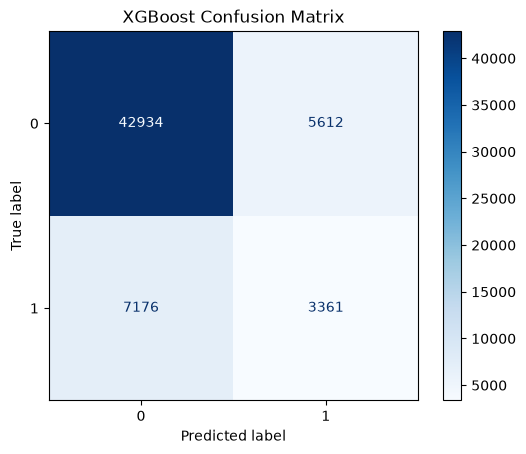

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

ROC-AUC Score: 0.6973117802568778


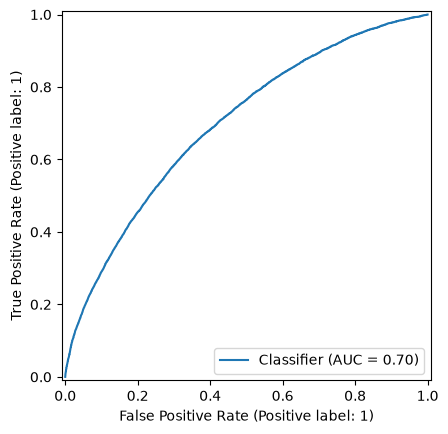

In [65]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

xgb_probs = xgb.predict_proba(X_test_encoded)[:, 1]

auc = roc_auc_score(y_test, xgb_probs)

print("ROC-AUC Score:", auc)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_probs
)

plt.show()

In [66]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
1257,num__Peak_Hour,0.241410
1253,num__Weekend,0.158601
1243,cat__Season_Spring,0.123595
1244,cat__Season_Summer,0.077431
1245,cat__Season_Winter,0.044406
1242,cat__Season_Autumn,0.026629
1251,num__DAY_OF_WEEK,0.024666
0,cat__AIRLINE_AA,0.023960
10,cat__AIRLINE_UA,0.022714
3,cat__AIRLINE_DL,0.021225


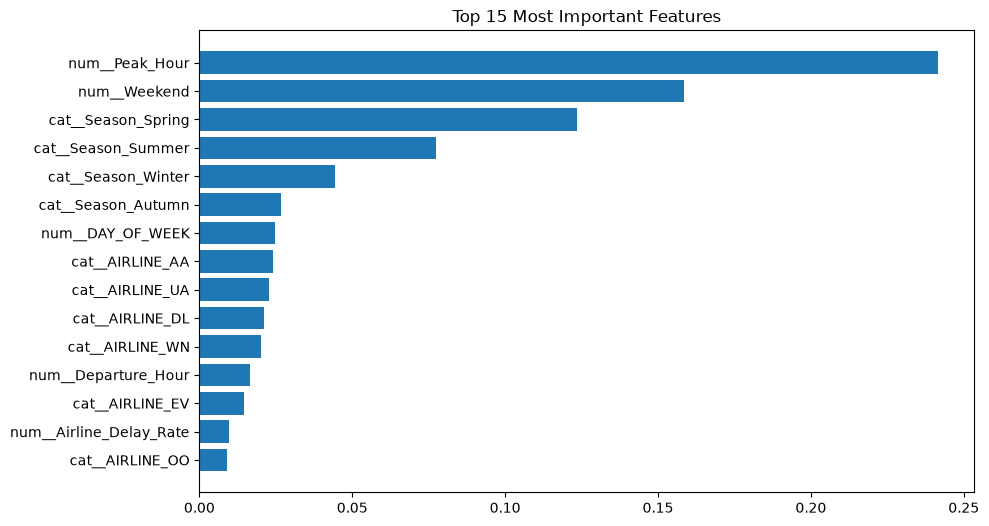

In [67]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features")

plt.show()

In [68]:
import joblib

joblib.dump(xgb, "../models/xgboost_model.pkl")

joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [69]:
results.to_csv("../models/model_results.csv", index=False)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.600596,0.248488,0.612318,0.353515
1,Decision Tree,0.810859,0.394928,0.113790,0.176674
2,Random Forest,0.771339,0.327372,0.267533,0.294443
3,XGBoost,0.822927,0.647059,0.015659,0.030578
